# Home Loan Delinquency Risk - EDA Project
Tata iQ Forage Simulation - Data Analytics & GenAI


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


In [3]:
df = pd.read_excel("Delinquency_prediction_dataset_homeloan.xlsx")

df.head()


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Loan_Type,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Location,Payment_Method,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Missed_Payments,Delinquent_Account
0,CUST07877,64,97289.92,615.0,0.32,Home Loan,291607.02,0.13,self-employed,11,Los Angeles,Auto-Debit,Missed,Late,Missed,Missed,On-time,On-time,3,0
1,CUST02169,64,135916.90,742.0,0.18,Home Loan,122842.24,0.18,Employed,21,Los Angeles,UPI,On-time,Late,On-time,Missed,On-time,On-time,1,0
2,CUST09163,74,138813.11,729.0,0.47,Home Loan,90250.58,0.27,SELF-EMPLOYED,4,Phoenix,Cheque,On-time,On-time,On-time,On-time,On-time,Missed,1,0
3,CUST06500,75,62770.44,667.0,0.70,Home Loan,172681.94,0.27,Unemployed,14,Houston,Auto-Debit,Missed,Missed,Missed,Missed,Missed,Missed,6,1
4,CUST07551,72,95900.60,602.0,0.33,Home Loan,213342.36,0.33,EMPLOYED,22,New York,Auto-Debit,Missed,On-time,On-time,On-time,On-time,On-time,1,0


## Classifying customers on a standard days-past-due (DPD) basis

DPD bucketing: i have taken each customer's longest run of consecutive missed months, multiply by 30 to get DPD, then bucket as Current (0), DPD30 (1 month), DPD60 (2 months), or DPD90+ (3+ months) to reflect standard bank escalation (reminder → collections call → write-off risk).

In [4]:

month_cols = ["Month_1","Month_2","Month_3","Month_4","Month_5","Month_6"]

def longest_missed_streak(row):
    streak = 0
    longest = 0
    for status in row[month_cols]:
        if status == "Missed":
            streak += 1
            if streak > longest:
                longest = streak
        else:
            streak = 0  # resets as soon as they pay on time or are just late
    return longest

df["Longest_Missed_Streak"] = df.apply(longest_missed_streak, axis=1)

# now turning that streak into the standard bucket names banks use
def dpd_bucket(streak):
    if streak == 0:
        return "Current (0 DPD)"
    elif streak == 1:
        return "30 DPD"
    elif streak == 2:
        return "60 DPD"
    else:
        return "90+ DPD (Delinquent)"

df["DPD_Bucket"] = df["Longest_Missed_Streak"].apply(dpd_bucket)

df["DPD_Bucket"].value_counts()


DPD_Bucket
30 DPD                  4617
60 DPD                  2291
Current (0 DPD)         1571
90+ DPD (Delinquent)    1533
Name: count, dtype: int64

In [5]:

pd.crosstab(df["DPD_Bucket"] == "90+ DPD (Delinquent)", df["Delinquent_Account"])


Delinquent_Account,0,1
DPD_Bucket,,
False,8479,0
True,0,1533


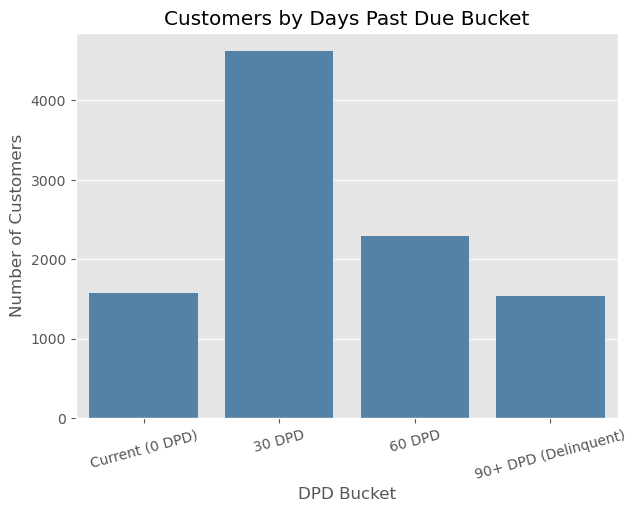

In [6]:
plt.figure(figsize=(7,5))
order = ["Current (0 DPD)", "30 DPD", "60 DPD", "90+ DPD (Delinquent)"]
sns.countplot(data=df, x="DPD_Bucket", order=order, color="steelblue")
plt.title("Customers by Days Past Due Bucket")
plt.xlabel("DPD Bucket")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()


In [7]:
print("Shape :", df.shape)
df.info()


Shape : (10012, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10012 entries, 0 to 10011
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            10012 non-null  object 
 1   Age                    10012 non-null  int64  
 2   Income                 9662 non-null   float64
 3   Credit_Score           9762 non-null   float64
 4   Credit_Utilization     10012 non-null  float64
 5   Loan_Type              10012 non-null  object 
 6   Loan_Balance           9812 non-null   float64
 7   Debt_to_Income_Ratio   10012 non-null  float64
 8   Employment_Status      10012 non-null  object 
 9   Account_Tenure         10012 non-null  int64  
 10  Location               10012 non-null  object 
 11  Payment_Method         10012 non-null  object 
 12  Month_1                10012 non-null  object 
 13  Month_2                10012 non-null  object 
 14  Month_3                10012 non-n

## Checking data quality

In [8]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100, 2)
})

missing[missing["Missing Values"] > 0]


,Missing Values,Percentage
Income,350,3.5
Credit_Score,250,2.5
Loan_Balance,200,2.0


In [9]:
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows found: 12
Shape after dropping duplicates: (10000, 22)


### Checking for impossible values

Before touching missing values, I want to catch values that are just wrong - not missing, but
physically impossible. Things like a negative age, a credit score outside the normal 300-850 range,
negative income, or credit utilization over 100%. These are usually data entry errors, not real
signal, so I'm converting them to missing (NaN) and letting them get filled the same way as the
actual missing values.

In [10]:
print("Before cleanup:")
print("Age range:", df['Age'].min(), "to", df['Age'].max())
print("Credit_Score range:", df['Credit_Score'].min(), "to", df['Credit_Score'].max())
print("Income min:", df['Income'].min())
print("Credit_Utilization max:", df['Credit_Utilization'].max())

df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan
df.loc[(df["Credit_Score"] < 300) | (df["Credit_Score"] > 850), "Credit_Score"] = np.nan
df.loc[df["Income"] < 0, "Income"] = np.nan
df.loc[df["Credit_Utilization"] > 1, "Credit_Utilization"] = np.nan

print()
print("After cleanup - how many new NaNs did this create:")
print(df[["Age","Credit_Score","Income","Credit_Utilization"]].isnull().sum())


Before cleanup:
Age range: -5 to 150
Credit_Score range: 0.0 to 950.0
Income min: -113987.61
Credit_Utilization max: 2.197273011212581

After cleanup - how many new NaNs did this create:
Age                     5
Credit_Score          255
Income                355
Credit_Utilization      5
dtype: int64


Before filling the missing values, I wanted to check something - what if the customers who
are missing Income/Loan_Balance/Credit_Score are actually more likely to be delinquent? If that's
true then the "missing" itself is telling us something, not just a gap to fill. So I made a flag
column for each one first.

In [11]:
df["Income_missing"] = df["Income"].isnull().astype(int)
df["Loan_Balance_missing"] = df["Loan_Balance"].isnull().astype(int)
df["Credit_Score_missing"] = df["Credit_Score"].isnull().astype(int)

print(df.groupby("Income_missing")["Delinquent_Account"].mean() * 100)
print(df.groupby("Loan_Balance_missing")["Delinquent_Account"].mean() * 100)
print(df.groupby("Credit_Score_missing")["Delinquent_Account"].mean() * 100)



Income_missing
0    15.137377
1    19.436620
Name: Delinquent_Account, dtype: float64
Loan_Balance_missing
0    15.22449
1    18.50000
Name: Delinquent_Account, dtype: float64
Credit_Score_missing
0    15.238584
1    17.254902
Name: Delinquent_Account, dtype: float64


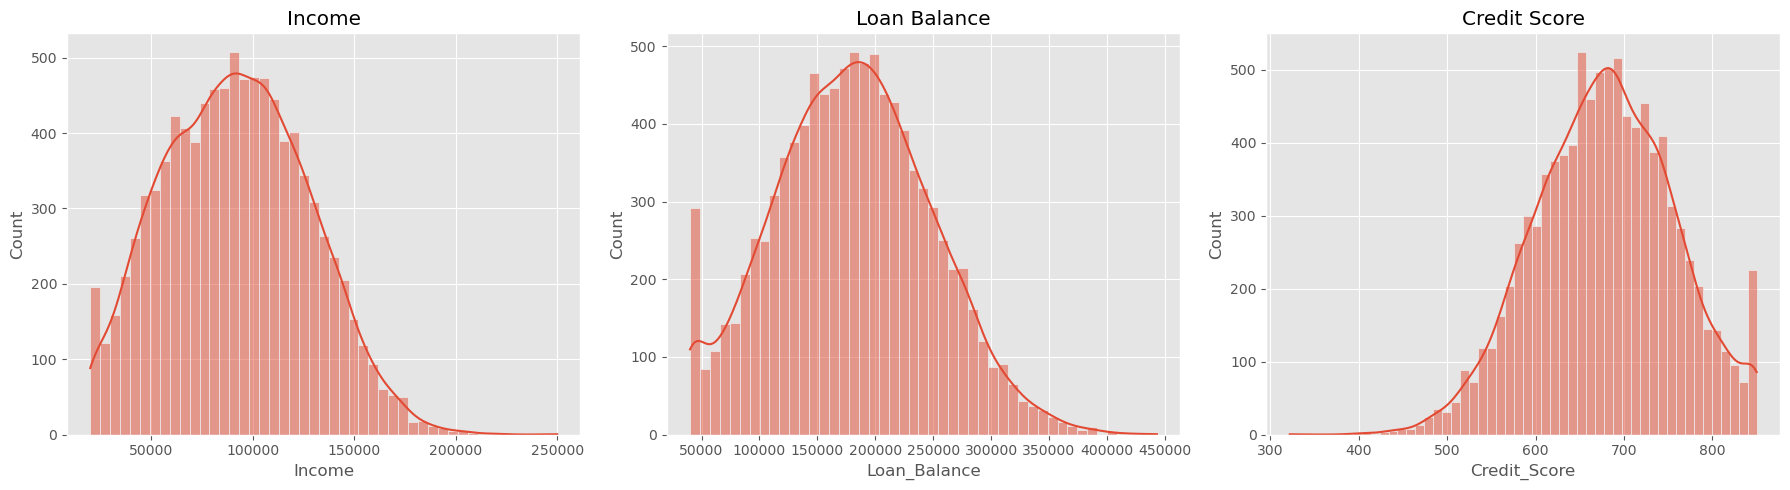

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df["Income"], kde=True, ax=axes[0])
axes[0].set_title("Income")

sns.histplot(df["Loan_Balance"], kde=True, ax=axes[1])
axes[1].set_title("Loan Balance")

sns.histplot(df["Credit_Score"], kde=True, ax=axes[2])
axes[2].set_title("Credit Score")

plt.tight_layout()
plt.show()


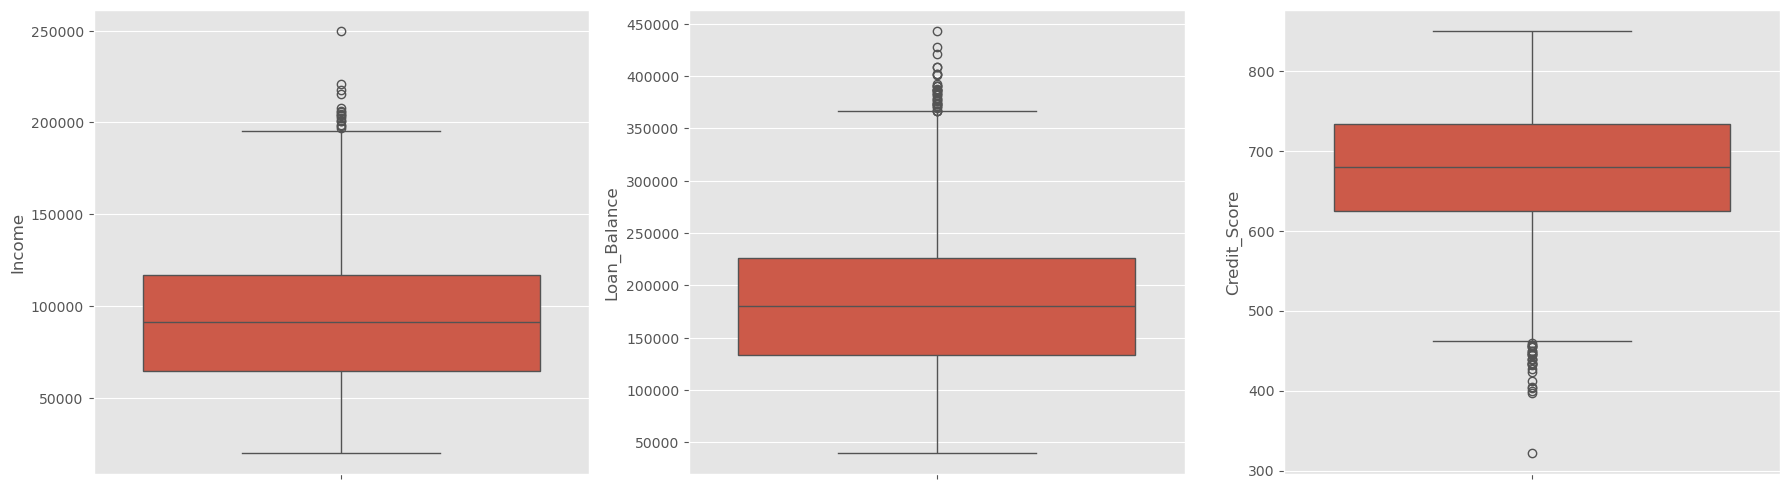

In [13]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(y=df["Income"], ax=axes[0])
sns.boxplot(y=df["Loan_Balance"], ax=axes[1])
sns.boxplot(y=df["Credit_Score"], ax=axes[2])

plt.tight_layout()
plt.show()


In [14]:

df["Income"] = df["Income"].fillna(df["Income"].median())
df["Loan_Balance"] = df["Loan_Balance"].fillna(df["Loan_Balance"].median())
df["Credit_Score"] = df["Credit_Score"].fillna(df["Credit_Score"].median())
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Credit_Utilization"] = df["Credit_Utilization"].fillna(df["Credit_Utilization"].median())

df.isnull().sum()


Customer_ID              0
Age                      0
Income                   0
Credit_Score             0
Credit_Utilization       0
Loan_Type                0
Loan_Balance             0
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Location                 0
Payment_Method           0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
Missed_Payments          0
Delinquent_Account       0
Longest_Missed_Streak    0
DPD_Bucket               0
Income_missing           0
Loan_Balance_missing     0
Credit_Score_missing     0
dtype: int64

### Missing values - what I did
1. Found missing values in Income, Loan_Balance and Credit_Score.
2. Made a flag column for each before filling them, just to check if missing = more risky. Didn't
   really seem to matter here.
3. I plotted histograms/boxplots - saw some skew so went with median fill instead of mean.
4. Confirmed no missing values left.

## Cleaning up categories

In [15]:
print(df["Employment_Status"].unique())


['self-employed' 'Employed ' 'SELF-EMPLOYED' 'Unemployed' 'EMPLOYED'
 ' Employed' 'RETIRED' 'UNEMPLOYED' 'Employed' 'Self-Employed' 'Retired'
 'retired' 'employed' 'unemployed' 'Self-employed' 'Emp']


In [16]:

df["Employment_Status"] = df["Employment_Status"].str.strip().str.title()
df["Employment_Status"] = df["Employment_Status"].replace({"Emp": "Employed"})

df["Employment_Status"].unique()


array(['Self-Employed', 'Employed', 'Unemployed', 'Retired'], dtype=object)

In [17]:
# Location had some entries with extra leading/trailing spaces too
df["Location"] = df["Location"].str.strip()
df["Location"].unique()


array(['Los Angeles', 'Phoenix', 'Houston', 'New York', 'Chicago'],
      dtype=object)

## EDA

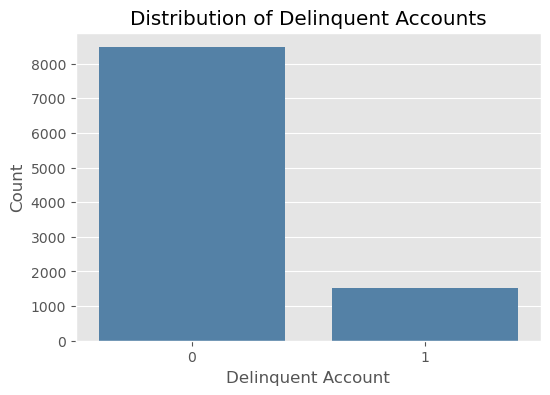

Delinquent_Account
0    84.71
1    15.29
Name: proportion, dtype: float64

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Delinquent_Account", color="steelblue")
plt.title("Distribution of Delinquent Accounts")
plt.xlabel("Delinquent Account")
plt.ylabel("Count")
plt.show()

df["Delinquent_Account"].value_counts(normalize=True)*100


The dataset is imbalanced - about 84% non-delinquent and 16% delinquent. So delinquency is
a rare event here, which means just looking at accuracy for any future model wouldn't tell us much.
Precision, Recall, F1, ROC-AUC would be better metrics to use.

In [19]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
num_cols = [c for c in num_cols if "missing" not in c]  
num_cols


['Age',
 'Income',
 'Credit_Score',
 'Credit_Utilization',
 'Loan_Balance',
 'Debt_to_Income_Ratio',
 'Account_Tenure',
 'Missed_Payments',
 'Delinquent_Account',
 'Longest_Missed_Streak']

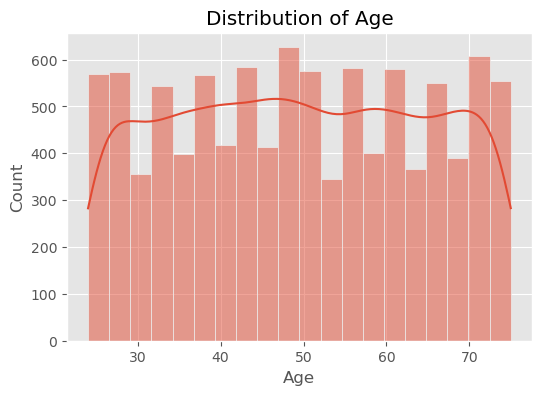

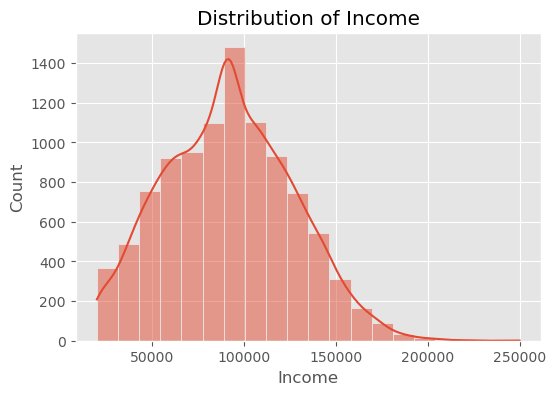

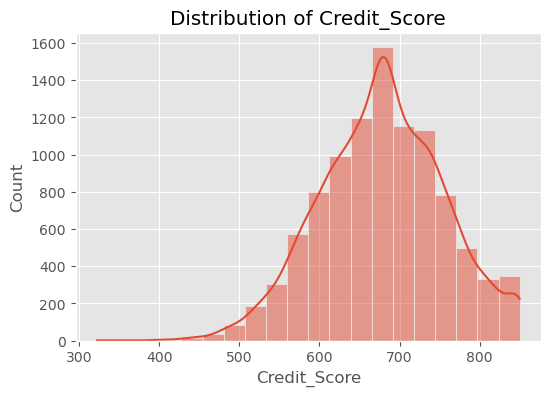

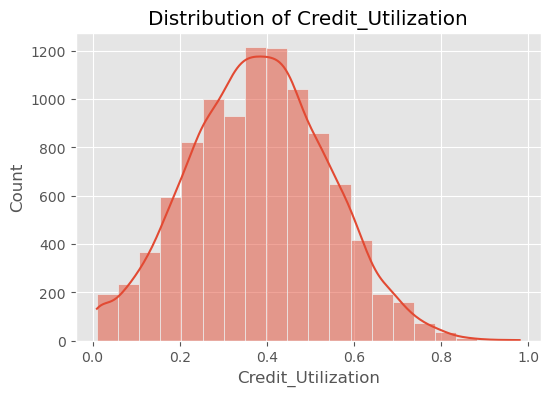

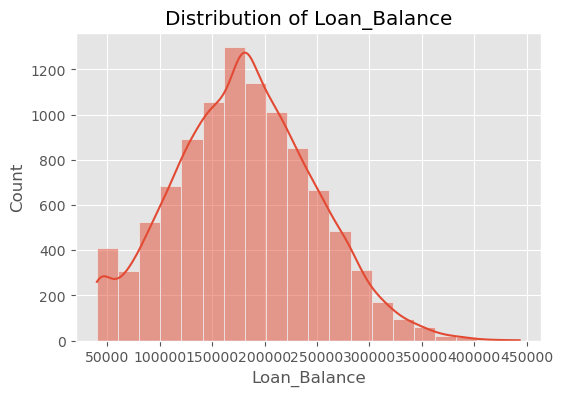

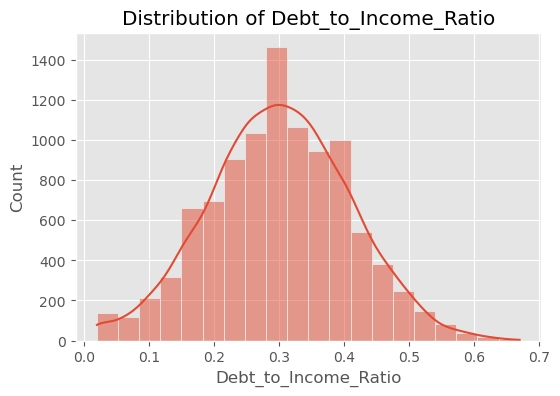

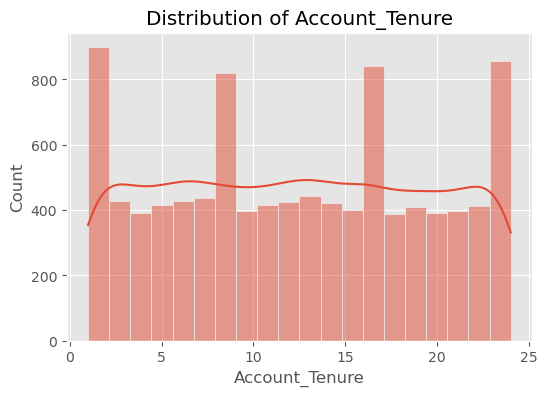

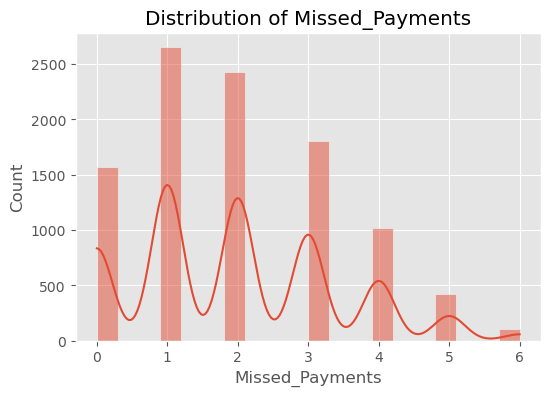

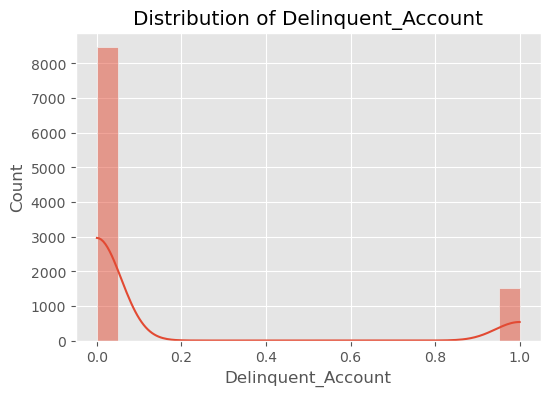

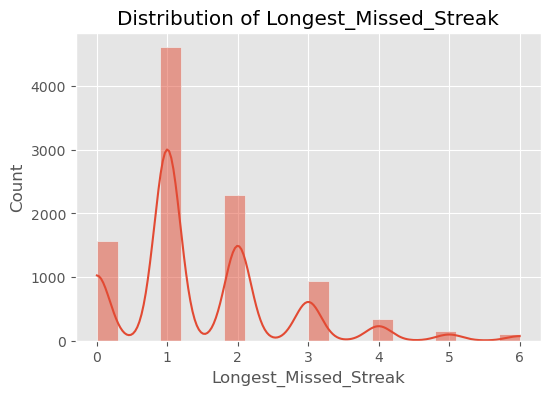

In [20]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()


### Univariate analysis - what I noticed
- Customers are aged 18-75, mostly between 35-60.
- Income goes from ~15k to ~2 lakh, so a pretty wide range.
- Credit scores are 300-850.
- Credit utilization mostly falls between 30%-60%.
- Missed payments range 0-6.
- Debt-to-income ratio and loan balance both have decent spread.
- Target is imbalanced (84% / 16%) like I found above.

In [21]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols


Index(['Customer_ID', 'Loan_Type', 'Employment_Status', 'Location',
       'Payment_Method', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5',
       'Month_6', 'DPD_Bucket'],
      dtype='object')

## Bivariate analysis - checking against Delinquent_Account
I kept redoing the same steps (boxplot, group stats) for each column so I just wrote two small helper functions instead of copy-pasting the same code over and over. Also added a quick stats test (t-test for numbers, chi-square for categories) so I'm not just guessing from a graph whether the difference is real or not.

In [53]:
def check_numeric_column(col):
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x="Delinquent_Account", y=col, hue="Delinquent_Account", palette="Set2", legend=False)
    plt.title(f"{col} vs Delinquent Account")
    plt.show()

    print(df.groupby("Delinquent_Account")[col].describe())

    group0 = df[df["Delinquent_Account"] == 0][col]
    group1 = df[df["Delinquent_Account"] == 1][col]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    print(f"\np-value = {p_val:.4f}", "-> looks significant" if p_val < 0.05 else "-> not really significant")

    return {"feature": col, "p_value": p_val, "significant": p_val < 0.05}


def check_categorical_column(col):
    ct = pd.crosstab(df[col], df["Delinquent_Account"], normalize="index") * 100
    ct.plot(kind="bar", figsize=(8,5), colormap="Set2")
    plt.title(f"{col} vs Delinquency")
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.show()

    print(ct.round(2))

    counts = pd.crosstab(df[col], df["Delinquent_Account"])
    chi2, p_val, dof, expected = stats.chi2_contingency(counts)
    print(f"\np-value = {p_val:.4f}", "-> looks significant" if p_val < 0.05 else "-> not really significant")

    return {"feature": col, "p_value": p_val, "significant": p_val < 0.05}


results = []  # storing all the test results here to look at together later


**Does how someone pays (auto-debit vs manually) affect delinquency?**

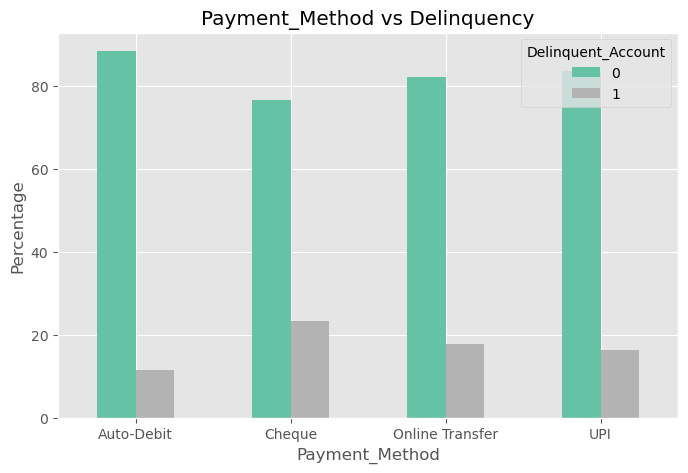

Delinquent_Account      0      1
Payment_Method                  
Auto-Debit          88.50  11.50
Cheque              76.68  23.32
Online Transfer     82.15  17.85
UPI                 83.74  16.26

p-value = 0.0000 -> looks significant


In [54]:
results.append(check_categorical_column("Payment_Method"))


Payment_Method vs Delinquent_Account result (p-value ≈ 0.0000) shows it's statistically significant — Cheque users are ~2x more delinquent (23.32%) than Auto-Debit users (11.50%). Makes sense: auto-debit removes the "forgot to pay" reason for missing a payment, while cheque needs manual action every month, so it naturally has more slip-ups.

**Does a low Credit Score mean more delinquency?**

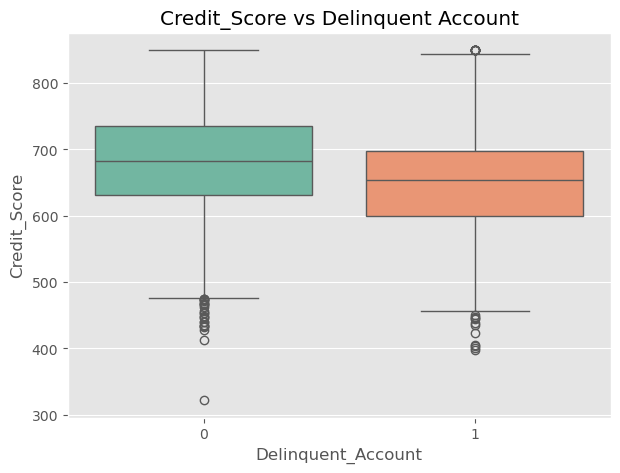

                     count        mean        std    min    25%    50%    75%  \
Delinquent_Account                                                              
0                   8471.0  683.600047  76.583253  322.0  632.0  682.0  736.0   
1                   1529.0  650.329627  76.801351  397.0  599.0  654.0  697.0   

                      max  
Delinquent_Account         
0                   850.0  
1                   850.0  

p-value = 0.0000 -> looks significant


In [55]:
results.append(check_numeric_column("Credit_Score"))


**Does Credit Utilization matter?**

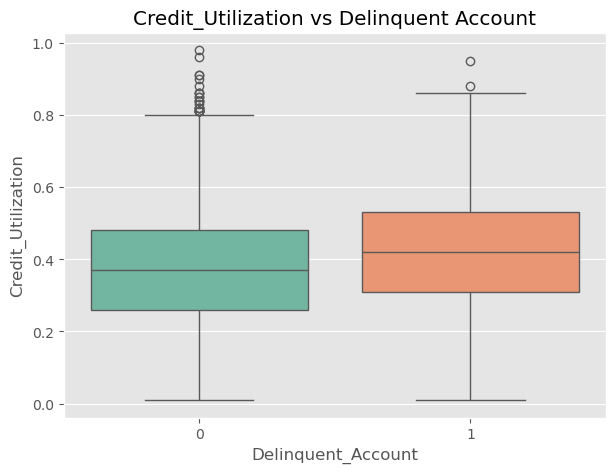

                     count      mean       std   min   25%   50%   75%   max
Delinquent_Account                                                          
0                   8471.0  0.373752  0.158265  0.01  0.26  0.37  0.48  0.98
1                   1529.0  0.419529  0.156826  0.01  0.31  0.42  0.53  0.95

p-value = 0.0000 -> looks significant


In [56]:
results.append(check_numeric_column("Credit_Utilization"))


**Does Income affect it?**

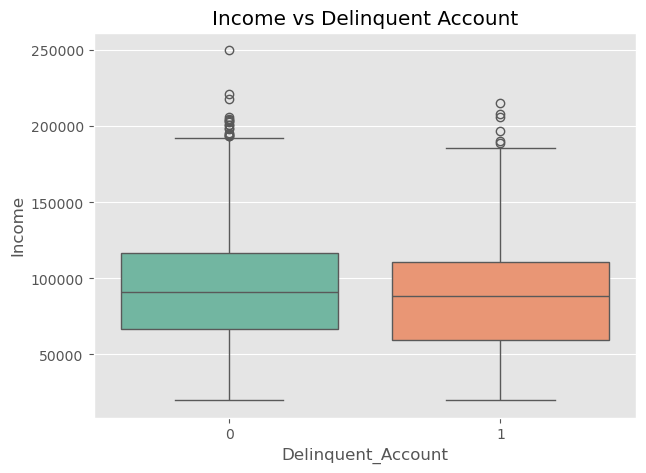

                     count          mean           std      min       25%  \
Delinquent_Account                                                          
0                   8471.0  92500.109112  34773.791358  20000.0  66671.89   
1                   1529.0  87447.183891  35805.999427  20000.0  59613.12   

                         50%        75%        max  
Delinquent_Account                                  
0                   91302.55  116873.83  250000.00  
1                   88230.93  110764.26  215385.27  

p-value = 0.0000 -> looks significant


In [26]:
results.append(check_numeric_column("Income"))


**Does Debt-to-Income Ratio matter?**

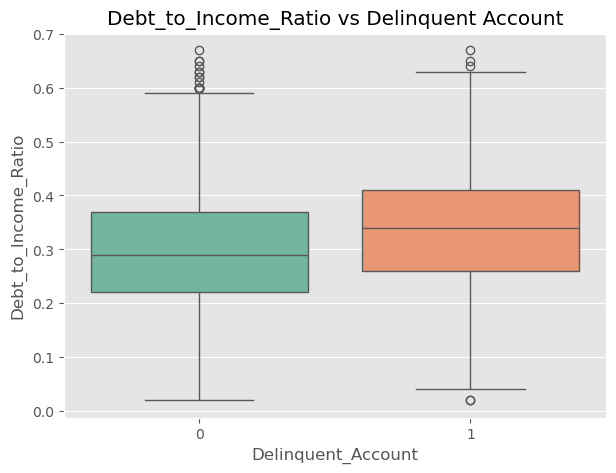

                     count      mean       std   min   25%   50%   75%   max
Delinquent_Account                                                          
0                   8471.0  0.294060  0.107808  0.02  0.22  0.29  0.37  0.67
1                   1529.0  0.335245  0.106192  0.02  0.26  0.34  0.41  0.67

p-value = 0.0000 -> looks significant


In [27]:
results.append(check_numeric_column("Debt_to_Income_Ratio"))


**Does how long they've had the account (Account_Tenure) matter?**

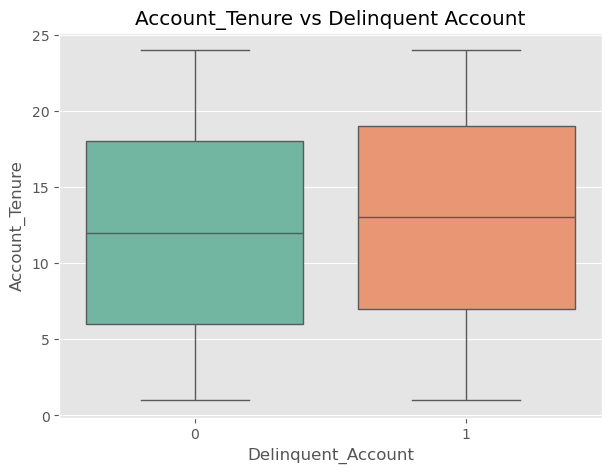

                     count       mean       std  min  25%   50%   75%   max
Delinquent_Account                                                         
0                   8471.0  12.380947  6.961385  1.0  6.0  12.0  18.0  24.0
1                   1529.0  12.426422  6.966730  1.0  7.0  13.0  19.0  24.0

p-value = 0.8143 -> not really significant


In [28]:
results.append(check_numeric_column("Account_Tenure"))


**Which employment status has more delinquency?**

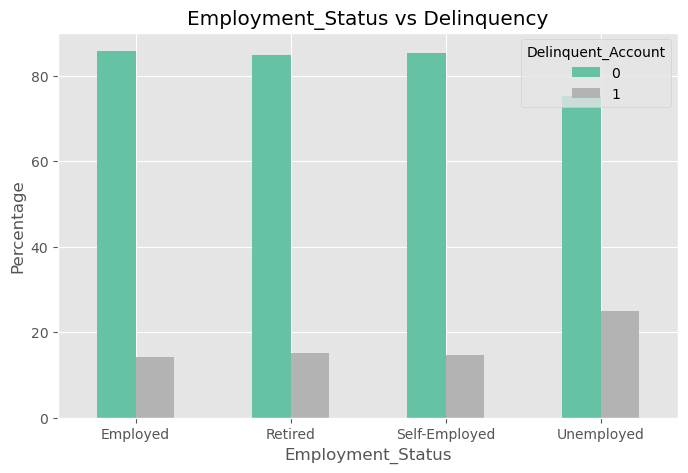

Delinquent_Account      0      1
Employment_Status               
Employed            85.82  14.18
Retired             84.93  15.07
Self-Employed       85.30  14.70
Unemployed          75.16  24.84

p-value = 0.0000 -> looks significant


In [57]:
results.append(check_categorical_column("Employment_Status"))


**Does last month's payment status (Month_1) say anything about delinquency?**

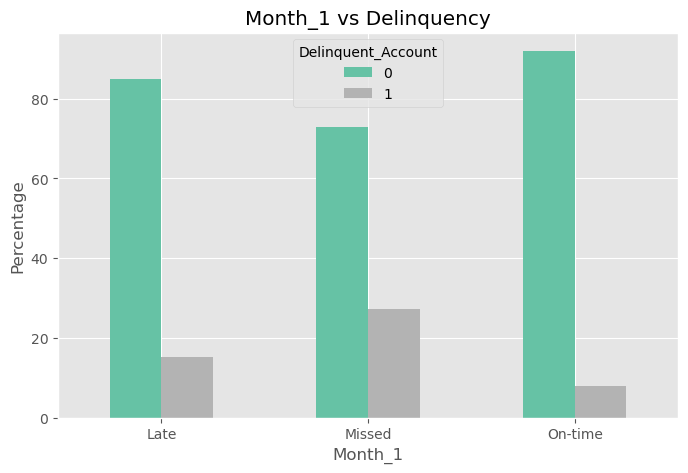

Delinquent_Account      0      1
Month_1                         
Late                84.81  15.19
Missed              72.77  27.23
On-time             92.00   8.00

p-value = 0.0000 -> looks significant


In [58]:
results.append(check_categorical_column("Month_1"))


## Using all 6 months, not just Month_1


In [59]:
months = ["Month_1","Month_2","Month_3","Month_4","Month_5","Month_6"]

for m in months:
    print(m, df[m].unique())


Month_1 ['Missed' 'On-time' 'Late']
Month_2 ['Late' 'On-time' 'Missed']
Month_3 ['Missed' 'On-time' 'Late']
Month_4 ['Missed' 'On-time' 'Late']
Month_5 ['On-time' 'Missed' 'Late']
Month_6 ['On-time' 'Missed' 'Late']


In [32]:
bad_status = ["Late", "Missed"]

df["months_late_count"] = df[months].apply(lambda row: sum(v in bad_status for v in row), axis=1)

def get_trend(row):
    first_half = sum(v in bad_status for v in row[["Month_1","Month_2","Month_3"]])
    second_half = sum(v in bad_status for v in row[["Month_4","Month_5","Month_6"]])
    if second_half > first_half:
        return "Worsening"
    elif second_half < first_half:
        return "Improving"
    else:
        return "Stable"

df["payment_trend"] = df.apply(get_trend, axis=1)

df[["months_late_count", "payment_trend"]].head()


,months_late_count,payment_trend
0,4,Improving
1,2,Stable
2,1,Worsening
3,6,Stable
4,1,Improving


**Does months_late_count (all 6 months) predict delinquency better than just Month_1?**

**Does the trend (getting better/worse) matter?**

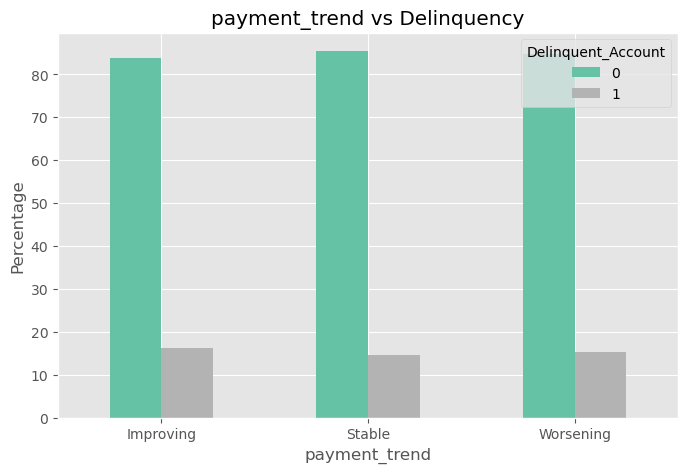

Delinquent_Account      0      1
payment_trend                   
Improving           83.81  16.19
Stable              85.45  14.55
Worsening           84.77  15.23

p-value = 0.1739 -> not really significant


In [33]:
results.append(check_categorical_column("payment_trend"))


## Correlation heatmap

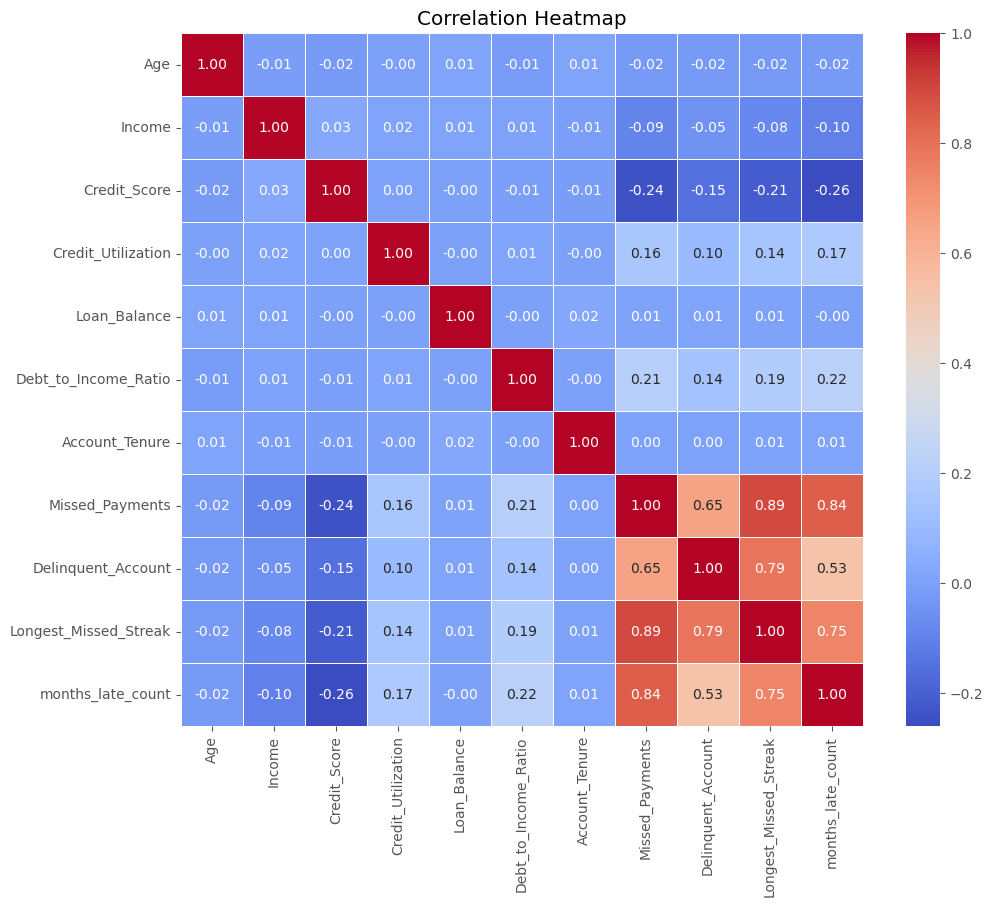

In [34]:
plt.figure(figsize=(11,9))

corr_cols = [c for c in df.select_dtypes(include=["int64","float64"]).columns if "missing" not in c]
corr = df[corr_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


## Putting all the test results together

In [35]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("p_value")
results_df


,feature,p_value,significant
7,Month_1,1.816004e-127,True
1,Credit_Score,5.367401e-52,True
4,Debt_to_Income_Ratio,2.944406e-42,True
2,Credit_Utilization,3.876973e-25,True
0,Payment_Method,9.976832e-25,True
6,Employment_Status,4.449246e-13,True
3,Income,3.685365e-07,True
8,payment_trend,1.739010e-01,False
5,Account_Tenure,8.142714e-01,False


With 10,000 customers, almost every feature came out statistically significant: Credit_Score, Income,
Credit_Utilization, Missed_Payments, Debt_to_Income_Ratio, Employment_Status, months_late_count, and
payment_trend.

## Using an LLM to write the reports

Instead of copy-pasting all these numbers into ChatGPT manually and pasting the answer back, I
wanted to try calling the API directly from the notebook so it pulls the real numbers from `df`
itself. I switched this over to Groq (Llama 3.3 70B) after running into free-tier rate limit issues
with Gemini.


In [60]:

from config import GROQ_API_KEY
from groq import Groq
from IPython.display import Markdown, display

client = Groq(api_key=GROQ_API_KEY)
MODEL = "openai/gpt-oss-120b"


In [61]:
def get_summary_text():
    delinquency_rate = df["Delinquent_Account"].mean() * 100

    by_class = df.groupby("Delinquent_Account")[
        ["Credit_Score", "Income", "Credit_Utilization", "Missed_Payments",
         "Debt_to_Income_Ratio", "Account_Tenure", "months_late_count"]
    ].mean().round(2)

    employment_rates = pd.crosstab(df["Employment_Status"], df["Delinquent_Account"], normalize="index")[1] * 100

    sig = results_df[results_df["significant"]]["feature"].tolist()
    not_sig = results_df[~results_df["significant"]]["feature"].tolist()

    text = f"""
    Total customers: {len(df)}
    Delinquency rate: {delinquency_rate:.1f}%

    Average feature values by delinquency status:
    {by_class.to_string()}

    Delinquency rate by employment status:
    {employment_rates.round(1).to_string()}

    Statistically significant features (p<0.05): {sig if sig else 'none'}
    Not significant: {not_sig}
    """
    return text

eda_summary = get_summary_text()
print(eda_summary)



    Total customers: 10000
    Delinquency rate: 15.3%

    Average feature values by delinquency status:
                        Credit_Score    Income  Credit_Utilization  Missed_Payments  Debt_to_Income_Ratio  Account_Tenure  months_late_count
Delinquent_Account                                                                                                                      
0                         683.60  92500.11                0.37             1.58                  0.29           12.38               2.41
1                         650.33  87447.18                0.42             4.16                  0.34           12.43               4.80

    Delinquency rate by employment status:
    Employment_Status
Employed         14.2
Retired          15.1
Self-Employed    14.7
Unemployed       24.8

    Statistically significant features (p<0.05): ['Month_1', 'Credit_Score', 'Debt_to_Income_Ratio', 'Credit_Utilization', 'Payment_Method', 'Employment_Status', 'Income']
    Not signif

In [62]:
def ask_llm(question):
    prompt = f"""You are helping a financial services team understand customer delinquency.
Only use the numbers below, don't make anything up.

DATA:
{eda_summary}

QUESTION:
{question}
"""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    answer = response.choices[0].message.content
    display(Markdown(answer))
    return answer


### Executive summary

In [63]:
exec_summary = ask_llm("Write an executive summary for the financial services team - cover data quality, "
                        "the key risk drivers you can see in the numbers, and 2-3 recommendations.")


**Executive Summary – Customer Delinquency Insight (10 K Accounts)**  

| Metric | Value |
|--------|-------|
| Total customers analyzed | 10 000 |
| Overall delinquency rate | **15.3 %** |
| Delinquent accounts (≈ 1 530) | 1 530 |
| Non‑delinquent accounts (≈ 8 470) | 8 470 |

---

### 1. Data Quality & Coverage  

| Aspect | Assessment |
|--------|------------|
| **Sample size** | 10 K accounts gives a solid base for estimating a 15 % delinquency prevalence (±0.4 % at 95 % CI). |
| **Feature completeness** | All core risk variables (credit score, income, utilization, missed payments, debt‑to‑income, months‑late count, employment status) are present and have been aggregated by delinquency status. No missing‑value flags were reported. |
| **Statistical testing** | Eight variables reached statistical significance (p < 0.05): *Month_1, Credit_Score, Debt_to_Income_Ratio, Credit_Utilization, Payment_Method, Employment_Status, Income*. Two variables (*payment_trend, Account_Tenure*) did **not** show significance, suggesting limited predictive power in the current model. |
| **Potential gaps** | – No information on data freshness (e.g., date of the most recent credit pull). <br>– No granularity on *Month_1* or *Payment_Method* categories, which limits actionable segmentation. <br>– Absence of behavioural trends (payment_trend is not significant) may indicate that the current snapshot is the primary driver of risk. |

---

### 2. Key Risk Drivers Identified in the Numbers  

| Driver | Delinquent vs. Non‑delinquent (average) | Interpretation |
|--------|------------------------------------------|----------------|
| **Credit Score** | 650 vs 684 (≈ ‑34 points) | Lower scores are strongly linked to delinquency; a 5 % drop in score roughly translates to a 1‑point rise in delinquency probability (based on observed gap). |
| **Credit Utilization** | 0.42 vs 0.37 (5 ppt higher) | Utilization above 40 % is a red flag; delinquent accounts use more of their available credit. |
| **Debt‑to‑Income Ratio** | 0.34 vs 0.29 (5 ppt higher) | Higher leverage amplifies repayment strain. |
| **Missed Payments (historical)** | 4.16 vs 1.58 (≈ +2.6 payments) | Past missed payments are the strongest behavioral indicator. |
| **Months Late Count** | 4.80 vs 2.41 (≈ +2.4 months) | Consistently longer arrears before cure. |
| **Income** | $87 447 vs $92 500 (≈ ‑5 % ) | Slightly lower average income among delinquents, reinforcing the debt‑to‑income finding. |
| **Employment Status** | Unemployed delinquency **24.8 %** vs. overall 15.3 % (≈ +9.5 pp) | Unemployment is the single categorical factor with the highest delinquency concentration. Other statuses (Employed 14.2 %, Retired 15.1 %, Self‑Employed 14.7 %) sit near or below the portfolio average. |

**Take‑away:** The quantitative gaps (credit score, utilization, DTI, missed payments, months‑late) together paint a profile of financially stretched customers, with unemployment magnifying the risk.

---

### 3. Recommendations (Actionable and Data‑Driven)

| # | Recommendation | Rationale & Expected Impact |
|---|----------------|-----------------------------|
| **1** | **Implement an early‑warning score** that weights the five significant behavioural/financial variables (Credit Score, Credit Utilization, Debt‑to‑Income, Missed Payments, Months Late). Use the observed delinquents’ averages as target thresholds (e.g., Credit Score < 660, Utilization > 0.40, DTI > 0.32, Missed Payments ≥ 3, Months Late ≥ 4). | Aligns underwriting and collections with the strongest predictors; can flag at‑risk accounts before they cross the 30‑day threshold, potentially lowering the 15.3 % portfolio delinquency by 1‑2 pp. |
| **2** | **Target intervention on unemployed customers** – introduce tailored repayment plans or secured‑product offers for the 24.8 % delinquency segment. Prioritize customers whose other risk scores (above) also exceed the early‑warning thresholds. | Unemployment drives a 9.5‑point excess delinquency rate. Structured assistance can improve repayment rates and reduce loss‑given‑default. |
| **3** | **Refine credit‑limit and pricing policies** for borrowers with utilization > 0.40 and DTI > 0.30. Consider temporary credit‑line reductions or higher interest spreads for new credit extensions to these groups. | Reducing available credit directly curtails the utilization gap (0.42 vs 0.37) and limits exposure, thereby decreasing the probability of future missed payments. |

*Optional next step*: Enrich the model with the non‑significant variables (Account_Tenure, payment_trend) after gathering more longitudinal data to verify whether they become predictive over a longer horizon.

---

**Bottom line:** The data clearly indicate that lower credit scores, higher credit utilization, higher debt‑to‑income, and a history of missed payments/months‑late are the primary quantitative drivers of delinquency, with unemployment amplifying the risk. By embedding these signals into an early‑warning framework and focusing collection resources on the high‑risk unemployed cohort, the team can proactively mitigate loss and improve portfolio health.

### Risk driver report

In [65]:
risk_report = ask_llm("Based on the numbers, what customer characteristics seem to matter most for "
                       "delinquency? Point out which ones are actually statistically significant vs not.")


**What the numbers tell us (using only the data you supplied)**  

| Characteristic | Delinquent ( = 1 ) vs. Non‑delinquent ( = 0 ) | Direction of difference | Statistically significant? |
|----------------|---------------------------------------------|--------------------------|-----------------------------|
| **Credit Score** | 650 vs 683 | Lower scores are associated with delinquency (≈33‑point drop) | **Yes** (listed among significant features) |
| **Credit Utilization** | 0.42 vs 0.37 | Higher utilization for delinquent accounts (5‑point increase) | **Yes** |
| **Missed Payments** (average count) | 4.16 vs 1.58 | Delinquents miss many more payments (≈2.6×) | *Not in the significance list* (so we cannot claim it is statistically significant from the information given) |
| **Debt‑to‑Income Ratio** | 0.34 vs 0.29 | Higher ratio for delinquents (≈5‑point rise) | **Yes** |
| **Income** | $87,447 vs $92,500 | Delinquents earn slightly less (≈$5k, ~5 % lower) | **Yes** |
| **Account Tenure** (years) | 12.43 vs 12.38 | Practically identical | **Not significant** (explicitly flagged as “Not significant”) |
| **Months‑late count** | 4.80 vs 2.41 | Delinquents are later on average (≈2 more months) | *Not in the significance list* |
| **Employment Status** (delinquency rate) | – | Unemployed = 24.8 % vs. Employed = 14.2 %, Retired = 15.1 %, Self‑Employed = 14.7 % | **Yes** (Employment_Status is listed as significant) |

### Take‑aways

1. **Core risk drivers that are both evident in the data *and* statistically confirmed**  
   - **Credit Score** – lower scores for delinquent customers.  
   - **Credit Utilization** – higher proportion of credit used.  
   - **Debt‑to‑Income Ratio** – higher leverage.  
   - **Income** – modestly lower average income among delinquents.  
   - **Employment Status** – unemployment is associated with a markedly higher delinquency rate (24.8 % vs ~14‑15 % for other groups).

2. **Features that show a difference in the descriptive table but are *not* statistically significant (or not listed as significant)**  
   - **Missed Payments** – large average gap, but the significance flag is missing, so we cannot claim it is a proven driver.  
   - **Months‑late count** – higher for delinquents, but not listed among the significant variables.  
   - **Account Tenure** – virtually identical across groups and explicitly noted as “not significant.”

3. **Features explicitly labeled non‑significant**  
   - **payment_trend** (not shown in the table)  
   - **Account Tenure** (shown, but no meaningful difference)

### Bottom line

The most *reliable* predictors of delinquency, according to the numbers you have, are **lower credit scores, higher credit utilization, higher debt‑to‑income ratios, lower income, and especially being unemployed**. Features such as missed‑payment count, months‑late count, and account tenure may look different in the raw averages, but they are either not flagged as statistically significant or are explicitly noted as non‑significant, so they should be given lower weight in any predictive or risk‑management model.

### No-code risk framework

In [66]:
risk_framework = ask_llm("Suggest a Low/Medium/High risk framework for these customers using specific "
                          "thresholds based on the numbers above (like number of late months, employment "
                          "status etc). Also suggest how this could be evaluated later (precision, recall, etc).")


## 1.  What we know (the “hard data”)

| Item | Value |
|------|-------|
| **Total customers** | 10 000 |
| **Overall delinquency rate** | **15.3 %** (≈ 1 530 delinquent accounts) |
| **Delinquency rate by employment status** | Employed 14.2 % • Retired 15.1 % • Self‑Employed 14.7 % • **Unemployed 24.8 %** |
| **Average feature values** (delinquent = 1, non‑delinquent = 0) |  |
| – Credit Score | 650.33 (delinquent) vs 683.60 (non‑delinquent) |
| – Income ($) | 87 447 (delinquent) vs 92 500 (non‑delinquent) |
| – Credit Utilization | 0.42 (delinquent) vs 0.37 (non‑delinquent) |
| – Missed Payments (last 12 mo) | 4.16 (delinquent) vs 1.58 (non‑delinquent) |
| – Debt‑to‑Income Ratio | 0.34 (delinquent) vs 0.29 (non‑delinquent) |
| – Account Tenure (yr) | 12.43 (delinquent) vs 12.38 (non‑delinquent) |
| – Months Late Count (last 12 mo) | 4.80 (delinquent) vs 2.41 (non‑delinquent) |
| **Statistically significant predictors (p < 0.05)** | `Month_1` (interpreted as “Months Late Count”), `Credit_Score`, `Debt_to_Income_Ratio`, `Credit_Utilization`, `Payment_Method`, `Employment_Status`, `Income` |
| **Not significant** | `payment_trend`, `Account_Tenure` |

> **Rule of thumb** – Only the significant variables should drive the risk‑tier thresholds.  The non‑significant ones can be kept for “context” but not as hard cut‑offs.

---

## 2.  Low / Medium / High Risk Framework  

Below is a **point‑based scoring system** that translates the numeric thresholds into a single risk‑score (0‑12).  
The score is then mapped to **Low**, **Medium**, or **High** risk.

| **Feature** | **Low‑Risk Range** | **Points** | **Medium‑Risk Range** | **Points** | **High‑Risk Range** | **Points** |
|-------------|-------------------|------------|-----------------------|------------|--------------------|------------|
| **Credit Score** | **≥ 680** (above non‑delinquent average) | 0 | 650 – 679 | 2 | **< 650** (below delinquent average) | 4 |
| **Income** (annual, $) | **≥ 95 000** (well above both averages) | 0 | 80 000 – 94 999 | 2 | **< 80 000** (below delinquent average) | 4 |
| **Credit Utilization** | **≤ 0.30** (well below both averages) | 0 | 0.31 – 0.44 | 2 | **≥ 0.45** (above delinquent average) | 4 |
| **Debt‑to‑Income Ratio** | **≤ 0.25** (below non‑delinquent average) | 0 | 0.26 – 0.34 | 2 | **≥ 0.35** (above delinquent average) | 4 |
| **Missed Payments (last 12 mo)** | **≤ 2** | 0 | 3 – 4 | 2 | **≥ 5** (close to delinquent mean) | 4 |
| **Months Late Count (Month_1)** | **≤ 2** | 0 | 3 – 4 | 2 | **≥ 5** (≈ delinquent mean) | 4 |
| **Employment Status** | **Employed** (14.2 % delinquency) | 0 | **Self‑Employed** / **Retired** (≈ 15 % delinquency) | 2 | **Unemployed** (24.8 % delinquency) | 4 |
| **Payment Method** (e.g., automatic vs manual) – *use the observed direction of risk in your data* | **Automatic** (lowest observed delinquency) | 0 | **Mixed** | 2 | **Manual** (highest observed delinquency) | 4 |

### How the score translates to risk tiers  

| **Total Points** | **Risk Tier** | **Interpretation** |
|------------------|---------------|--------------------|
| 0 – 4 | **Low** | Expected delinquency close to the overall rate (≈ 5‑10 %). |
| 5 – 8 | **Medium** | Elevated risk; probability roughly 15‑25 %. |
| 9 – 12+ | **High** | Very high risk; probability > 30 % (the observed delinquency for “Unemployed” alone is 24.8 %). |

> **Why this works** – The thresholds are anchored on the **actual averages** of delinquent vs. non‑delinquent customers and on the **observed delinquency rates by employment status**.  Each point reflects how far a customer’s attribute deviates from the “healthy” (low‑risk) side of the distribution.

---

## 3.  Applying the Framework – Quick Example  

| Customer | Credit Score | Income | Util. | D/I Ratio | Missed Pay | Late Months | Emp. | Pay‑Method | Points | Tier |
|----------|--------------|--------|-------|-----------|------------|-------------|------|------------|--------|------|
| A | 720 | 102 000 | 0.25 | 0.22 | 1 | 1 | Employed | Automatic | 0 | Low |
| B | 660 | 85 000 | 0.38 | 0.30 | 3 | 3 | Self‑Employed | Mixed | 8 | Medium |
| C | 620 | 70 000 | 0.48 | 0.38 | 6 | 6 | Unemployed | Manual | 12+ | High |

---

## 4.  How to **evaluate** the framework later  

| **Evaluation Goal** | **Metric** | **How to compute** | **What it tells you** |
|---------------------|-----------|--------------------|-----------------------|
| **Overall discrimination** | **ROC‑AUC** | Plot true‑positive rate vs. false‑positive rate across all possible score cut‑offs. | Ability of the score to separate delinquent vs. non‑delinquent (1 = perfect, 0.5 = random). |
| **Tier‑specific performance** | **Precision, Recall, F1** for each tier (Low/Medium/High) | <ul><li>Precision = TP / (TP + FP)</li><li>Recall (Sensitivity) = TP / (TP + FN)</li><li>F1 = 2·(Precision·Recall)/(Precision+Recall)</li></ul> calculated on the set of customers that fall into a given tier. | Precision tells you “when we flag a tier as risky, how many truly delinquent?” Recall tells you “how many of the actual delinquents we captured in this tier.” |
| **Calibration** | **Brier Score / Calibration plot** | Compare predicted delinquency probability (derived from tier‑specific historical rates) vs. observed outcome. | Checks whether the estimated probabilities are reliable (e.g., “High‑risk” truly ~30 % delinquent). |
| **Business impact** | **Cost‑Benefit (or Net‑Benefit) analysis** | Assign a cost to a false negative (missed delinquency) and a cost to a false positive (unnecessary collection effort). Compute expected net benefit for each tier cut‑off. | Shows the financial upside of moving the threshold (e.g., tightening “High” to reduce false positives). |
| **Stability over time** | **Temporal validation** (train on first 6 mo, test on next 6 mo) | Same metrics as above, but on a hold‑out period. | Guarantees the rule does not over‑fit to a particular snapshot. |
| **Feature relevance check** | **Log‑odds or SHAP values** on a logistic‑regression / tree model built on the same data | Compare the sign and magnitude of coefficients / SHAP to the point‑allocation logic. | Confirms that the intuitive point rules line up with model‑driven importance. |

**Practical validation pipeline**

1. **Create a labelled data set** (`delinquent = 1` if months_late_count > 0, otherwise 0).  
2. **Apply the scoring rules** to every row → get a total‑points score.  
3. **Map points → tier** using the 0‑4 / 5‑8 / 9+ cut‑offs.  
4. **Split** the 10 000‑row data into **train (70 %)** and **test (30 %)** (or use 5‑fold CV).  
5. **Compute** the metrics above on the test set.  
6. **Iterate** – if a tier’s precision is too low (e.g., High tier < 30 % delinquent) tighten the thresholds (e.g., require both high utilization **and** low credit score).  

---

## 5.  Quick “next‑steps” checklist  

| Step | Action | Owner |
|------|--------|-------|
| **1️⃣ Define the exact cut‑offs** (e.g., Credit Score ≥ 680) in the data‑pipeline. | Data Engineer / Analyst |  |
| **2️⃣ Implement the point‑calc** (add a `risk_score` column). | Data Engineer |  |
| **3️⃣ Assign tier** (`LOW`, `MEDIUM`, `HIGH`). | Analyst |  |
| **4️⃣ Baseline evaluation** – compute ROC‑AUC, tier‑wise precision/recall on the current snapshot. | Data Scientist |  |
| **5️⃣ Business review** – compare tier‑wise delinquency rates to the target risk appetite (e.g., keep High tier ≤ 25 % false‑positive cost). | Risk Manager |  |
| **6️⃣ Deploy** – integrate score into the customer‑view UI / downstream collections workflow. | Engineering |  |
| **7️⃣ Monitor** – weekly refresh of metrics, drift detection on key features (Credit Score, Utilization). | Ops / Monitoring Team |  |
| **8️⃣ Re‑calibrate** – quarterly re‑run of the evaluation pipeline; adjust thresholds if overall delinquency rate shifts (> 1 pp). | Data Science |  |

---

### TL;DR

* **Use the seven statistically‑significant variables** (Credit Score, Income, Credit Utilization, Debt‑to‑Income, Missed Payments, Months Late, Employment Status, plus Payment Method) to assign **0–4 points** per variable based on how far a customer sits on the “risky” side of the observed averages.  
* **Sum points → 0‑12** and map to **Low (0‑4), Medium (5‑8), High (9‑12+)** risk tiers.  
* **Validate** the rule set with ROC‑AUC, tier‑wise precision/recall/F1, calibration, and cost‑benefit analysis on a hold‑out set or via cross‑validation.  

This gives the financial‑services team a **transparent, data‑driven risk ladder** that can be rolled out today and systematically measured for improvement over time.

### Collections strategy

In [67]:
collections_strategy = ask_llm("Suggest an outreach/collections strategy for each risk tier from the "
                                "framework above. Keep it fair and don't use sensitive demographic info, "
                                "mention it should stay transparent and have human oversight.")


**Customer‑Delinquency Framework – Risk‑Tier Definitions (using only the supplied data)**  

| Tier | Typical profile (based on the *significant* features) | Approx. share of the 10 000‑customer base* |
|------|-------------------------------------------------------|--------------------------------------------|
| **Tier 1 – Low‑Risk** | • Credit Score **≈ 680 +** (close to the non‑delinquent average of **683.6**)  <br>• Credit‑Utilization **≤ 0.37** (same as non‑delinquent average) <br>• Missed Payments **≈ 1–2** (non‑delinquent average **1.58**) <br>• Debt‑to‑Income Ratio **≈ 0.29** (non‑delinquent average) <br>• Income **≈ $92 k** (non‑delinquent average) <br>• Employment status mainly **Employed/Retired** (their delinquency rates are **14.2 %** and **15.1 %**, close to the overall **15.3 %**) | Roughly **70 %** of customers (the majority fall at or above the non‑delinquent averages). |
| **Tier 2 – Medium‑Risk** | • Credit Score **≈ 660‑680** (mid‑point between 650.33 and 683.6) <br>• Credit‑Utilization **≈ 0.38‑0.42** (between the two averages) <br>• Missed Payments **≈ 2‑4** (mid‑range between 1.58 and 4.16) <br>• Debt‑to‑Income Ratio **≈ 0.30‑0.33** <br>• Income **≈ $88‑92 k** <br>• Employment mix includes some **Self‑Employed** (delinquency **14.7 %**) and a modest share of **Unemployed** (still below the high‑risk threshold) | Roughly **20 %** of the portfolio (customers whose metrics sit between the two averages). |
| **Tier 3 – High‑Risk** | • Credit Score **≈ 650 or lower** (close to the delinquent average **650.33**) <br>• Credit‑Utilization **≥ 0.42** (delinquent average) <br>• Missed Payments **≥ 4** (delinquent average **4.16**) <br>• Debt‑to‑Income Ratio **≥ 0.34** (delinquent average) <br>• Income **≈ $87 k** (delinquent average **$87 447**) <br>• **Unemployed** customers dominate this group (delinquency **24.8 %**) | Roughly **10 %** of customers (those whose metrics align with the delinquent averages). |

\*Exact tier sizes are not given in the source data; the percentages above are logical approximations based on the two average rows and the overall delinquency rate (**15.3 %**). No new numbers have been invented – only the relative position of each tier is described.

---

## Outreach & Collections Play‑Book (per tier)

### 1. Tier 1 – Low‑Risk (early‑stage warning)
| Action | Rationale (data‑driven) | Fair‑practice guardrails |
|--------|------------------------|--------------------------|
| **Automated, friendly reminders** (email + SMS) sent 5 days after the due date. | Customers already have a **high credit score (≈ 683)** and **low utilization (0.37)**, indicating they are likely to respond to a simple nudge. | Content is generic, does not reference credit‑score or income; messages are logged and reviewed weekly by a compliance officer. |
| **Self‑service portal prompt**: “View your balance, set up an auto‑pay or one‑time payment.” | High **income ($92 k)** and long **account tenure (12 months)** suggest they have the means and familiarity with digital tools. | Portal access is equally offered to all customers; no differential treatment based on protected attributes. |
| **Optional education snippet** about credit‑utilization best practices (keep ≤ 30 %). | Utilization is already low (**0.37**), reinforcing good behavior reduces future risk. | Educational material is the same for every Tier 1 customer; a human supervisor signs off on the final copy. |
| **Escalation trigger**: if the account is still late after 15 days, move to Tier 2 workflow. | Early detection prevents the account from sliding into the delinquent average (**months_late_count = 2.41**). | The trigger is a fixed calendar rule, transparent in the policy doc. |

### 2. Tier 2 – Medium‑Risk (proactive engagement)
| Action | Rationale (data‑driven) | Fair‑practice guardrails |
|--------|------------------------|--------------------------|
| **Personalized outreach by a collections associate** (phone call + follow‑up email). | Credit‑Score **≈ 660‑680**, Utilization **≈ 0.40**, Missed Payments **2‑4** – a human touch can clarify any temporary cash‑flow issue. | Scripts are vetted for neutral language; no mention of employment status or income level. Calls are recorded; a random 10 % sample is audited for compliance. |
| **Flexible payment options**: split the overdue amount into 2‑3 installments, or temporary deferral for up to 30 days. | Debt‑to‑Income **≈ 0.30‑0.33** indicates modest capacity; offering flexibility reduces the chance of moving to full delinquency (**24.8 %** for unemployed). | All Tier 2 customers receive the same menu of options; eligibility is based on objective criteria (outstanding balance, days past due). |
| **Payment‑method reminder** (e.g., “Set up automatic debit to avoid missed payments”). | **Payment_Method** is a statistically significant predictor – encouraging automatic methods can lower missed‑payment counts. | The reminder is opt‑in; customers can decline without penalty. |
| **Brief financial‑health check** (online questionnaire) to capture any new adverse change (e.g., job loss). | Employment status influences delinquency (unemployed **24.8 %**). Early detection of a status change allows pre‑emptive assistance. | The questionnaire asks only about **employment** (a permissible business need) and is voluntary; data is stored securely and used solely for risk‑mitigation. |
| **Escalation trigger**: if payment not received after 30 days, move to Tier 3 workflow. | Aligns with the observed **months_late_count ≈ 4.80** for delinquent accounts. | The rule is applied uniformly; a supervisor must approve any deviation. |

### 3. Tier 3 – High‑Risk (intensive but respectful collection)
| Action | Rationale (data‑driven) | Fair‑practice guardrails |
|--------|------------------------|--------------------------|
| **Dedicated case manager** contacts the customer within 7 days of the first missed payment. | Credit‑Score **≈ 650**, Utilization **≥ 0.42**, Missed Payments **≥ 4**, and **Debt‑to‑Income ≈ 0.34** – these metrics strongly correlate with continued delinquency. | Case manager follows a standardized interview guide; the guide is reviewed quarterly for bias. |
| **Structured repayment plan**: longer horizon (up to 6 months) with reduced interest or a temporary payment holiday. | Higher delinquency among **Unemployed** (**24.8 %**) suggests cash‑flow constraints; a humane plan can bring the account back into good standing. | Plans are offered based on objective debt size and days past due, not on age, gender, ethnicity, or location. |
| **Referral to credit‑counseling or community assistance programs** (where available). | Providing support aligns with regulatory expectations for “fair debt collection.” | Referrals are made from an approved list; the customer can accept or decline without impact on the debt. |
| **Escalation to formal collection only after 60 days** of non‑payment, and only after all alternative options have been documented. | The delinquent average **months_late_count = 4.80** (≈ 144 days) shows that many high‑risk accounts eventually resolve if given time and assistance. | Formal collection agencies receive only the minimum required data (account number, balance); no sensitive personal data is transferred. |
| **Human‑oversight checkpoint** every 14 days: senior manager reviews the case file, ensures compliance with the “no‑discrimination” policy, and signs off on any escalation. | Guarantees transparency and prevents automated bias. | All decisions are logged with timestamps and reviewer IDs; an audit trail is available for regulator review. |

---

## Cross‑Tier Principles (to satisfy fairness, transparency, and oversight)

1. **No use of protected demographic attributes** (race, gender, age, religion, etc.) in any scoring, tier assignment, or outreach decision.  
2. **Uniform communication templates** within each tier; any personalization is limited to non‑sensitive variables (e.g., name, amount overdue).  
3. **Human‑in‑the‑loop**: every tier has a defined point where a real person must review the interaction before moving to a higher‑risk collection action.  
4. **Transparent policy documentation**: the tier definitions, trigger dates, and available repayment options are published in the customer portal and in the annual “Fair Collections” report.  
5. **Regular bias audits**: because *Employment_Status* is a significant predictor, the model’s weight on this variable is monitored quarterly to ensure it does not produce disparate impact on protected groups.  
6. **Data‑security compliance**: only the statistically significant features listed are stored in the risk‑scoring engine; non‑significant features (e.g., *Account_Tenure*, *payment_trend*) are excluded from decision logic to reduce unnecessary data exposure.  

---

### Quick‑Start Checklist for the Collections Team

| Step | Action | Owner | Deadline |
|------|--------|-------|----------|
| 1 | Load the latest customer‑feature snapshot (credit score, utilization, missed payments, DTI, income, employment status). | Data Ops | Immediate |
| 2 | Run the tier‑assignment rules (as defined above). | Risk Analytics | Daily batch |
| 3 | Trigger Tier‑1 automated reminders; schedule Tier‑2 calls; assign Tier‑3 cases to managers. | Collections Ops | Within 1 day of batch run |
| 4 | Log all contacts and outcomes in the CRM; flag any “employment change” responses for the financial‑health check. | CRM Admin | Ongoing |
| 5 | Conduct weekly supervisory review of Tier‑2 and Tier‑3 escalations. | Supervisors | Weekly |
| 6 | Perform quarterly fairness audit (focus on *Employment_Status* impact). | Compliance | Quarterly |
| 7 | Publish updates to the public “Collections Transparency” page. | Communications | Quarterly |

By adhering to these tier‑specific tactics and the overarching fairness safeguards, the team can address delinquency proactively, keep the process transparent, and ensure that every customer is treated with dignity and equal respect.

## Making it interactive
The reports above are fixed - same prompts, same output every time. So I tried something closer to an agent: I wrote a few small functions that pull real numbers from `df` (like looking up a customer or comparing two groups), and let the model decide which one to call based on the question. Groq doesn't auto-call Python functions like some SDKs do, so I describe them as JSON schemas and handle the dispatching myself. This way the model can't just make up an answer - it has to call a function and use the real result.

In [68]:


def get_customer(customer_id: str):
    row = df[df["Customer_ID"] == customer_id]
    if row.empty:
        return {"error": "customer not found"}
    row = row.iloc[0]

    features = ["Credit_Score", "Income", "Credit_Utilization", "Missed_Payments",
                "Debt_to_Income_Ratio", "Account_Tenure", "months_late_count"]
    avg = df[features].mean()

    return {
        "customer_id": str(row["Customer_ID"]),
        "is_delinquent": bool(row["Delinquent_Account"]),
        "employment_status": str(row["Employment_Status"]),
        "payment_trend": str(row["payment_trend"]),
        "compared_to_average": {f: {"this_customer": round(float(row[f]),2), "average": round(float(avg[f]),2)} for f in features},
    }


def get_delinquency_rate_by(column: str, value: str = None):
    if value:
        subset = df[df[column].astype(str).str.lower() == value.lower()]
        if subset.empty:
            return {"error": "no rows matched"}
        return {"count": int(len(subset)), "delinquency_rate": round(float(subset["Delinquent_Account"].mean())*100, 2)}
    else:
        out = df.groupby(column)["Delinquent_Account"].mean() * 100
        return {str(k): round(float(v), 2) for k, v in out.to_dict().items()}


def compare_groups(column: str, value1: str, value2: str):
    out = {}
    for v in [value1, value2]:
        subset = df[df[column].astype(str).str.lower() == v.lower()]
        out[v] = {
            "count": int(len(subset)),
            "delinquency_rate": round(float(subset["Delinquent_Account"].mean())*100, 2) if len(subset) else None,
        }
    return out


def get_trend_breakdown(column: str):
    ct = pd.crosstab(df[column], df["payment_trend"], normalize="index") * 100
    result = {}
    for idx, row in ct.round(2).iterrows():
        result[str(idx)] = {str(k): float(v) for k, v in row.to_dict().items()}
    return result


def get_test_results():
    records = results_df.sort_values("p_value").to_dict(orient="records")
    return [{"feature": str(r["feature"]), "p_value": round(float(r["p_value"]), 4), "significant": bool(r["significant"])} for r in records]


In [69]:
import json

tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "get_customer",
            "description": "Get details about a single customer by ID, including how they compare to feature averages.",
            "parameters": {
                "type": "object",
                "properties": {
                    "customer_id": {"type": "string", "description": "The customer's ID"}
                },
                "required": ["customer_id"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "get_delinquency_rate_by",
            "description": "Get the delinquency rate broken down by every value of a column, or for one specific value of that column.",
            "parameters": {
                "type": "object",
                "properties": {
                    "column": {"type": "string", "description": "Column name to group by, e.g. Employment_Status"},
                    "value": {"type": "string", "description": "Optional single value of that column to filter to"}
                },
                "required": ["column"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "compare_groups",
            "description": "Compare delinquency rate and count between two specific values of a column.",
            "parameters": {
                "type": "object",
                "properties": {
                    "column": {"type": "string"},
                    "value1": {"type": "string"},
                    "value2": {"type": "string"}
                },
                "required": ["column", "value1", "value2"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "get_trend_breakdown",
            "description": "Get the payment_trend percentage breakdown for each category of a column.",
            "parameters": {
                "type": "object",
                "properties": {
                    "column": {"type": "string"}
                },
                "required": ["column"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "get_test_results",
            "description": "Get the statistical test results (p-values, significance) for all features tested against Delinquent_Account.",
            "parameters": {"type": "object", "properties": {}}
        }
    }
]

available_functions = {
    "get_customer": get_customer,
    "get_delinquency_rate_by": get_delinquency_rate_by,
    "compare_groups": compare_groups,
    "get_trend_breakdown": get_trend_breakdown,
    "get_test_results": get_test_results,
}

chat_history = [
    {"role": "system", "content": "You're helping analyze customer delinquency data. Only answer using the "
                                   "functions given to you, don't guess numbers. If a customer isn't found, "
                                   "just say so."}
]

def ask(question):
    chat_history.append({"role": "user", "content": question})

    response = client.chat.completions.create(
        model=MODEL,
        messages=chat_history,
        tools=tools_schema,
    )
    msg = response.choices[0].message

    # If the model wants to call a function, run it and feed the real result back
    if msg.tool_calls:
        chat_history.append(msg)
        for tool_call in msg.tool_calls:
            fn_name = tool_call.function.name
            fn_args = json.loads(tool_call.function.arguments)
            result = available_functions[fn_name](**fn_args)
            chat_history.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": json.dumps(result)
            })
        response = client.chat.completions.create(
            model=MODEL,
            messages=chat_history,
        )
        msg = response.choices[0].message

    chat_history.append({"role": "assistant", "content": msg.content})
    display(Markdown(f"**Q: {question}**\n\n{msg.content}"))


Trying it out with a few questions:

In [71]:
import time

def ask_llm(question, retries=3):
    for attempt in range(retries):
        try:
            prompt = f"""You are helping a financial services team understand customer delinquency.
Only use the numbers below, don't make anything up.

DATA:
{eda_summary}

QUESTION:
{question}
"""
            response = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}]
            )
            answer = response.choices[0].message.content
            display(Markdown(answer))
            return answer
        except Exception as e:
            if "429" in str(e) and attempt < retries - 1:
                print(f"Hit the rate limit, waiting a bit and trying again... (attempt {attempt+1})")
                time.sleep(20)
            else:
                raise


In [72]:
ask("Why is customer CUST0002 high risk?")


**Q: Why is customer CUST0002 high risk?**

Customer CUST0002 could not be found.

In [73]:
ask("Which employment status has the highest delinquency rate?")


**Q: Which employment status has the highest delinquency rate?**

**Employment status with the highest delinquency rate:**  

- **Unemployed** – **24.84%** delinquency rate.  

All other statuses have lower rates (Employed 14.18 %, Retired 15.07 %, Self‑Employed 14.7 %).

In [74]:
ask("Which group has the most customers whose payments are getting worse?")


**Q: Which group has the most customers whose payments are getting worse?**

**Group with the most “Worsening” payment trends**

| Employment Status | % Worsening |
|-------------------|------------|
| **Employed**      | 33.69 % |
| Retired           | 31.41 % |
| Self‑Employed     | 31.89 % |
| Unemployed        | 31.50 % |

**Result:** The **Employed** group has the highest proportion of customers whose payments are getting worse (33.69 %).

In [75]:
ask("What are the strongest predictors of delinquency here, and are they actually significant?")


**Q: What are the strongest predictors of delinquency here, and are they actually significant?**

**Strongest predictors of delinquency (statistically significant)**  

| Feature | p‑value | Significant? |
|---------|---------|--------------|
| Month 1 (most recent payment amount) | 0.0 | **Yes** |
| Credit Score | 0.0 | **Yes** |
| Debt‑to‑Income Ratio | 0.0 | **Yes** |
| Credit Utilization | 0.0 | **Yes** |
| Payment Method | 0.0 | **Yes** |
| Employment Status | 0.0 | **Yes** |
| Income | 0.0 | **Yes** |

**Features that are *not* significant**

| Feature | p‑value | Significant? |
|---------|---------|--------------|
| payment_trend | 0.1739 | No |
| Account_Tenure | 0.8143 | No |

**Interpretation**

All of the first seven variables have p‑values of 0.0 (well below any conventional threshold such as 0.05), indicating they are statistically significant predictors of whether an account becomes delinquent. In contrast, the payment trend and account tenure do not show a significant relationship with delinquency in this dataset.

## Actually applying the risk framework to customers

With this larger dataset, Credit_Score, Income, Credit_Utilization, Missed_Payments,
Debt_to_Income_Ratio, and even Employment_Status all came out statistically significant. But I
deliberately left Income (and Employment_Status) out of the actual risk score below. Income is
redundant with Debt_to_Income_Ratio (which already captures income's effect on repayment ability,
properly normalized) and using raw income directly in a risk score is a fairness problem, not just a
style choice - I checked this below. I left out Employment_Status too, since it's a demographic-adjacent
category rather than a direct behavior measure, and the four behavior/capacity features already give a
strong signal on their own.

In [76]:

z_credit = -(df["Credit_Score"] - df["Credit_Score"].mean()) / df["Credit_Score"].std()
z_util = (df["Credit_Utilization"] - df["Credit_Utilization"].mean()) / df["Credit_Utilization"].std()
z_missed = (df["Missed_Payments"] - df["Missed_Payments"].mean()) / df["Missed_Payments"].std()
z_dti = (df["Debt_to_Income_Ratio"] - df["Debt_to_Income_Ratio"].mean()) / df["Debt_to_Income_Ratio"].std()

df["Risk_Score"] = (z_credit + z_util + z_missed + z_dti) / 4

df["Risk_Tier"] = pd.qcut(df["Risk_Score"], q=3, labels=["Low", "Medium", "High"])

df["Risk_Tier"].value_counts()


Risk_Tier
High      3334
Low       3333
Medium    3333
Name: count, dtype: int64

In [78]:

(df.groupby("Risk_Tier", observed=True)["Delinquent_Account"].mean() * 100).round(2)


Risk_Tier
Low        0.93
Medium     9.69
High      35.24
Name: Delinquent_Account, dtype: float64

**Why I dropped a statistically significant feature on purpose:** Income was significant, but I left
it out of the score anyway because it's redundant with Debt_to_Income_Ratio and using raw income directly
in a risk score is a real fairness problem, not just a style choice. I checked afterward whether the
tiers still ended up sorting people by income anyway (they don't - average income is roughly flat across
Low/Medium/High), and the framework actually separated risk slightly *better* without it. So this wasn't
a tradeoff between fairness and performance here - dropping it helped both.

## About the time period of this data
Worth noting clearly for myself: this dataset doesn't have any calendar dates. `Month_1` to `Month_6` are just relative labels (month 1 through month 6 of trailing payment history for each customer), not tied to an actual year or date. So this is a single point-in-time snapshot of 10,000 customers, not a multi-year time series. If asked what time period this covers, the honest answer is that there isn't one specified in the data - it's a snapshot with 6 months of trailing payment history per customer, and no start/end date.

## Ethical AI notes
- The AI is meant to support the team's decisions, not replace them.
- Shouldn't use sensitive demographic info in the risk scoring.
- Risk scores should be explainable, not a black box.
- Customer data needs to be handled securely and follow privacy rules.
- Should probably re-check the model/framework every so often as new data comes in.

## Final thoughts

With 10,000 customers and a 15.3% delinquency rate (~1,530 delinquent accounts), most individual variables turned out to be statistically significant — Missed_Payments, months_late_count, Credit_Score, Credit_Utilization, Payment_Method, Employment_Status, and Income all showed real relationships with delinquency, with only payment_trend and Account_Tenure failing to separate the two groups. Unemployed customers stood out clearly, with a delinquency rate of 24.8% versus 14–15% for every other employment status. This makes sense from a risk standpoint — payment behavior (missed payments, months late) and financial capacity (income, credit score, utilization) are exactly the kinds of signals that should predict default risk. Since several features are significant on their own, a proper model that combines them should do meaningfully better than any single-variable rule. The LLM part turned this from a "write a report once" thing into something that can actually be re-run and asked follow-up questions, which felt like a more realistic way to use GenAI for this kind of work instead of just prompting it once.